# Phase 3 — ARIMA Forecasting (Model 1)
### Target: `GDP_Growth` — India Quarterly (2010-Q1 → 2025-Q4)

| | |
|---|---|
| **Model** | ARIMA(p, d, q) — order selected via AIC with auto_arima |
| **Target** | GDP Annual Growth Rate (%) |
| **Split** | Chronological 80 / 20 train / test |
| **Metrics** | RMSE, MAPE |
| **Output** | `models/arima_results.json` |

> GDP_Growth is **I(1)** per the ADF tests in Phase 2. ARIMA handles integration internally
> via the *d* parameter (the number of differences applied before fitting AR+MA components).


In [1]:
import sys, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT       = Path("..").resolve()
DATA_PATH  = ROOT / "data" / "processed" / "india_macro_quarterly.csv"
MODELS_DIR = ROOT / "models"
DOCS_DIR   = ROOT / "docs"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

# ── Add src to path so we can import model_arima ───────────────────────────
sys.path.insert(0, str(ROOT / "src"))
from model_arima import load_series, fit_arima, forecast_arima, evaluate_forecast

# ── Style ───────────────────────────────────────────────────────────────────
BG_COLOR   = "#0f1117"
GRID_COLOR = "#2a2d3a"
TEXT_COLOR = "#e0e0e0"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR, "axes.facecolor":   BG_COLOR,
    "axes.edgecolor":   GRID_COLOR,"axes.labelcolor": TEXT_COLOR,
    "axes.titlecolor":  TEXT_COLOR,"axes.grid":       True,
    "grid.color":       GRID_COLOR,"grid.linewidth":  0.6,
    "xtick.color":      TEXT_COLOR,"ytick.color":     TEXT_COLOR,
    "text.color":       TEXT_COLOR,"legend.facecolor":"#1a1d27",
    "legend.edgecolor": GRID_COLOR,"font.size":       11,
})
print("Imports OK")


Imports OK


## § 1 — Load Data & Train / Test Split

**Why chronological split?**

Time series observations are not i.i.d. — each value depends on its past (autocorrelation).
Randomly shuffling would:
1. Cause **data leakage** — the model would "see" future values during training
2. Destroy **temporal ordering** — exactly what ARIMA's AR/MA components model

A strict chronological split (earliest 80% → train, latest 20% → test) mirrors
real-world deployment where only historical data is available at forecast time.


In [2]:
# Load real dataset
series = load_series(column="GDP_Growth", data_path=DATA_PATH)
print(f"Series: {series.index[0].date()} → {series.index[-1].date()}  ({len(series)} quarters)")
print()

# Chronological 80/20 split
TRAIN_RATIO = 0.80
n_train = int(len(series) * TRAIN_RATIO)
train   = series.iloc[:n_train]
test    = series.iloc[n_train:]

print(f"Train : {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} quarters)")
print(f"Test  : {test.index[0].date()}  → {test.index[-1].date()}   ({len(test)} quarters)")


Series: 2010-01-01 → 2025-10-01  (64 quarters)

Train : 2010-01-01 → 2022-07-01  (51 quarters)
Test  : 2022-10-01  → 2025-10-01   (13 quarters)


## § 2 — Automatic (p, d, q) Order Selection via AIC

`pmdarima.auto_arima` performs a stepwise search over the (p, d, q) grid, selecting the
combination that minimises the **Akaike Information Criterion**:

$$AIC = 2k - 2\ln(\hat{L})$$

where k = number of free parameters and L̂ = maximised likelihood.
A lower AIC favours a better-fitting model while penalising extra parameters.

`d` is determined automatically via ADF tests on the training series.


In [3]:
# Fit ARIMA (auto-select order)
result = fit_arima(train)
order  = result.model.order
print(f"\nSelected order: ARIMA{order}")
print(f"AIC = {result.aic:.4f}  |  BIC = {result.bic:.4f}")


Running auto_arima to select optimal (p, d, q) …
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=345.703, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=249.586, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=251.513, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=251.519, Time=0.02 sec


 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=244.390, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=283.164, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=245.342, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=245.632, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=253.401, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.08 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.365 seconds

Best order → p=1, d=0, q=0
AIC = 244.3899

Fitting statsmodels ARIMA(1, 0, 0) …
                               SARIMAX Results                                
Dep. Variable:             GDP_Growth   No. Observations:                   51
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -119.195
Date:                Mon, 17 Aug 2026   AIC                            244.390
Time:                        23:56:21   BIC                            250.185


## § 3 — Out-of-Sample Forecast

The fitted model is used to produce point forecasts for the **test period** only.
No future data leaks into the forecast — the model sees only `train` during fitting.
A 95 % confidence interval is also computed.


In [4]:
fc = forecast_arima(result, steps=len(test), index=test.index)

forecast  = fc["forecast"]
conf_int  = fc["conf_int"]

forecast_df = pd.DataFrame({
    "Actual":     test,
    "Forecast":   forecast,
    "Lower_95CI": conf_int.iloc[:, 0],
    "Upper_95CI": conf_int.iloc[:, 1],
}).round(4)

display(forecast_df)


,Actual,Forecast,Lower_95CI,Upper_95CI
2022-10-01,7.6094,7.2306,2.3589,12.1024
2023-01-01,7.2102,6.9514,0.8983,13.0044
2023-04-01,7.2102,6.7454,0.1381,13.3528
2023-07-01,7.2102,6.5936,-0.2965,13.4836
2023-10-01,7.2102,6.4816,-0.5574,13.5206
2024-01-01,7.0993,6.3990,-0.7197,13.5177
2024-04-01,7.0993,6.3381,-0.8235,13.4998
2024-07-01,7.0993,6.2932,-0.8917,13.4782
2024-10-01,7.0993,6.2601,-0.9374,13.4577
2025-01-01,7.5667,6.2357,-0.9687,13.4401


## § 4 — Evaluation Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RMSE** | √[(1/n) Σ(yᵢ − ŷᵢ)²] | Same units as GDP_Growth; penalises large errors more |
| **MAPE** | (100/n) Σ|yᵢ − ŷᵢ| / |yᵢ| | Scale-independent; expressed as percentage |

MAPE excludes any observations where the actual value is exactly zero.


In [5]:
print("── Evaluation ──────────────────────────")
metrics = evaluate_forecast(test, forecast)
print("────────────────────────────────────────")


── Evaluation ──────────────────────────
  RMSE : 0.9236
  MAPE : 11.46 %
────────────────────────────────────────


## § 5 — Forecast Plot: Actual vs. Predicted

Dark-themed time-series plot showing:
- **Blue line**: training history (actual)
- **Green dashed**: test actuals (the ground truth)
- **Orange line + dots**: ARIMA point forecast
- **Orange ribbon**: 95 % confidence interval


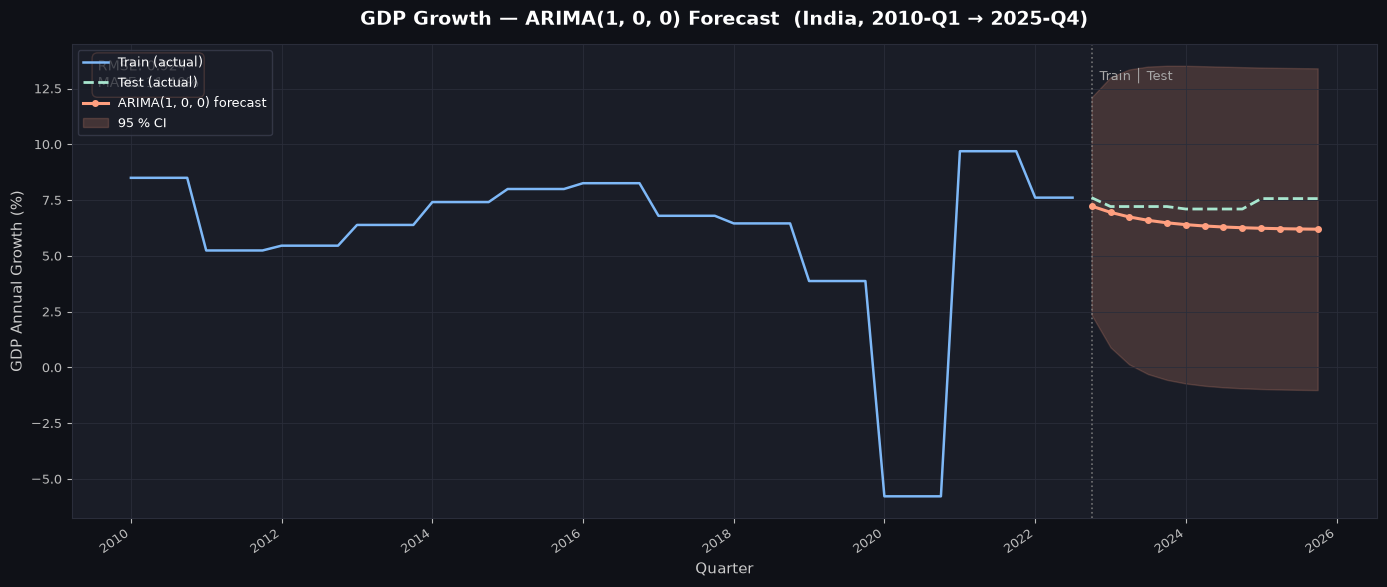

Plot saved → docs/arima_forecast.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor("#1a1d27")
for spine in ax.spines.values():
    spine.set_edgecolor(GRID_COLOR)

# Training
ax.plot(train.index, train.values,
        color="#7eb8f7", linewidth=1.8, label="Train (actual)", zorder=3)

# Test actuals
ax.plot(test.index, test.values,
        color="#a8e6cf", linewidth=2.0, linestyle="--",
        label="Test (actual)", zorder=4)

# Forecast
ax.plot(forecast.index, forecast.values,
        color="#ff9f7f", linewidth=2.2, marker="o", markersize=4,
        label=f"ARIMA{order} forecast", zorder=5)

# 95 % CI
ax.fill_between(
    conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
    color="#ff9f7f", alpha=0.18, label="95 % CI",
)

# Split line
split_date = test.index[0]
ax.axvline(split_date, color="#888", linestyle=":", linewidth=1.2, alpha=0.8)
ylim = ax.get_ylim()
ax.text(split_date, ylim[1] - (ylim[1] - ylim[0]) * 0.05,
        "  Train │ Test", color="#aaa", fontsize=9, va="top")

# Metrics box
metrics_txt = f"RMSE: {metrics['RMSE']:.3f}\nMAPE: {metrics['MAPE']:.2f}%"
ax.text(0.02, 0.97, metrics_txt,
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#2a2d3a",
                  edgecolor="#ff9f7f", alpha=0.85),
        color="white")

ax.set_title(f"GDP Growth — ARIMA{order} Forecast  (India, 2010-Q1 → 2025-Q4)",
             fontsize=14, color="white", pad=14, fontweight="bold")
ax.set_xlabel("Quarter", color="#ccc", fontsize=11)
ax.set_ylabel("GDP Annual Growth (%)", color="#ccc", fontsize=11)
ax.tick_params(colors="#bbb", labelsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=35, ha="right")
ax.legend(fontsize=9, facecolor="#1a1d27", edgecolor="#3a3d4d",
          labelcolor="white", loc="upper left")
ax.grid(True, color=GRID_COLOR, linewidth=0.6, zorder=0)

plt.tight_layout()
fig.savefig(DOCS_DIR / "arima_forecast.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Plot saved → docs/arima_forecast.png")


In [7]:
results_dict = {
    "model":  "ARIMA",
    "target": "GDP_Growth",
    "order":  list(order),
    "train_period": {
        "start": str(train.index[0].date()),
        "end":   str(train.index[-1].date()),
    },
    "test_period": {
        "start": str(test.index[0].date()),
        "end":   str(test.index[-1].date()),
    },
    "n_train": int(len(train)),
    "n_test":  int(len(test)),
    "metrics": {
        "RMSE": round(metrics["RMSE"], 6),
        "MAPE": round(metrics["MAPE"], 6),
    },
    "aic": round(float(result.aic), 4),
    "bic": round(float(result.bic), 4),
}

out_path = MODELS_DIR / "arima_results.json"
with open(out_path, "w") as f:
    json.dump(results_dict, f, indent=2)

print("Results saved → models/arima_results.json")
print()
print(json.dumps(results_dict, indent=2))


Results saved → models/arima_results.json

{
  "model": "ARIMA",
  "target": "GDP_Growth",
  "order": [
    1,
    0,
    0
  ],
  "train_period": {
    "start": "2010-01-01",
    "end": "2022-07-01"
  },
  "test_period": {
    "start": "2022-10-01",
    "end": "2025-10-01"
  },
  "n_train": 51,
  "n_test": 13,
  "metrics": {
    "RMSE": 0.923632,
    "MAPE": 11.460149
  },
  "aic": 244.3899,
  "bic": 250.1853
}
